In [8]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


EDA (Exploratory Data Analysis)

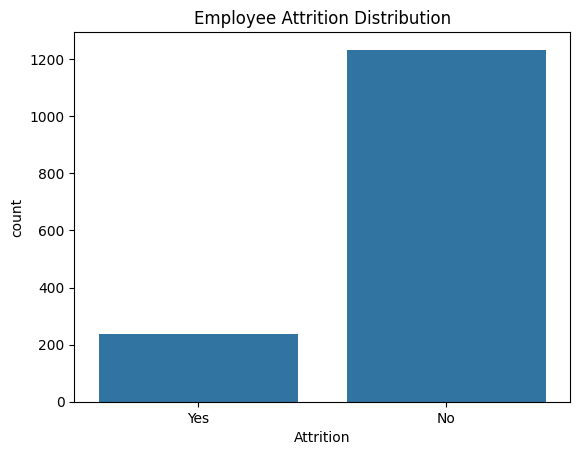

In [9]:
sns.countplot(x='Attrition',data=df)
plt.title('Employee Attrition Distribution')
plt.show()

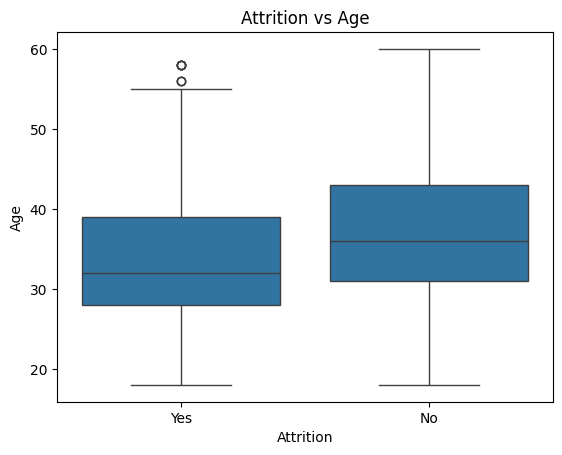

In [6]:
sns.boxplot(x='Attrition', y='Age',data=df)
plt.title('Attrition vs Age')
plt.show()

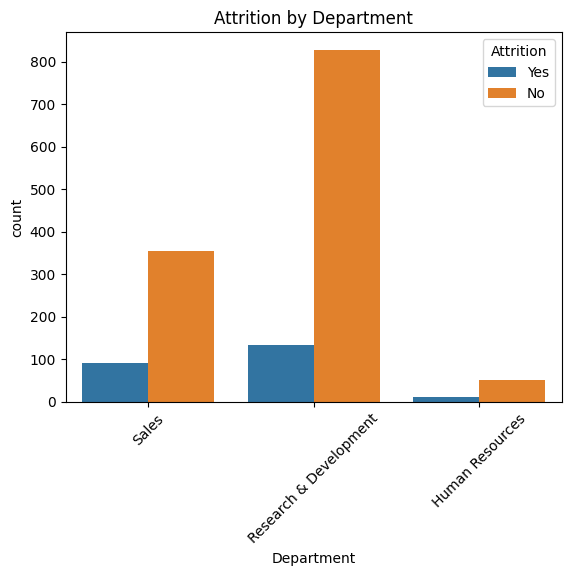

In [7]:
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Attrition by Department')
plt.xticks(rotation=45)
plt.show()

Data Preprocessing

In [12]:
df.drop(['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], axis=1, inplace=True)

In [13]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split 

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training data: {X_train.shape}, test data:{X_test.shape} ')

Training data: (1176, 34), test data:(294, 34) 


Trian the Model

1. Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset (replace with your actual dataset path)
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Define your feature columns and target column
X = df.drop('Attrition', axis=1)
y = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)  # Convert target to 1/0

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training data: {X_train.shape}, test data:{X_test.shape} ')

# List of categorical columns to apply OneHotEncoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Create a ColumnTransformer to apply OneHotEncoder on categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols)
    ], 
    remainder='passthrough'  # Keep other columns as they are
)

# Create a pipeline that first transforms data and then fits a Logistic Regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('log_reg', LogisticRegression(max_iter=1000))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict on the test data
y_pred_log_reg = pipeline.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred_log_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))


Training data: (1176, 34), test data:(294, 34) 
Logistic Regression Accuracy:  0.8639455782312925
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.45      0.13      0.20        39

    accuracy                           0.86       294
   macro avg       0.67      0.55      0.56       294
weighted avg       0.82      0.86      0.83       294

Confusion Matrix:
 [[249   6]
 [ 34   5]]


2. Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Assuming X and y are already preprocessed
# Convert categorical columns using One-Hot Encoding (or Label Encoding if needed)
X = pd.get_dummies(df.drop('Attrition', axis=1))  # One-hot encode categorical features
y = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)  # Convert target variable to binary

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy:  0.8775510204081632
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.15      0.25        39

    accuracy                           0.88       294
   macro avg       0.78      0.57      0.59       294
weighted avg       0.86      0.88      0.84       294

Confusion Matrix:
 [[252   3]
 [ 33   6]]


Model Evaluation and Interpretation

In [19]:
pip install --upgrade numba llvmlite


  Using cached numba-0.61.2-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.44.0-cp313-cp313-win_amd64.whl.metadata (5.0 kB)
Using cached numba-0.61.2-cp313-cp313-win_amd64.whl (2.8 MB)
Using cached llvmlite-0.44.0-cp313-cp313-win_amd64.whl (30.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install shap --no-binary :all:


  Using cached shap-0.47.1.tar.gz (2.5 MB)
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [1039 lines of output]
           ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
           ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
           ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
           ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
           ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
           ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
           ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
           ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
           ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
           ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
           --------------- ------------------------ 0.5/1.4 MB 228.2

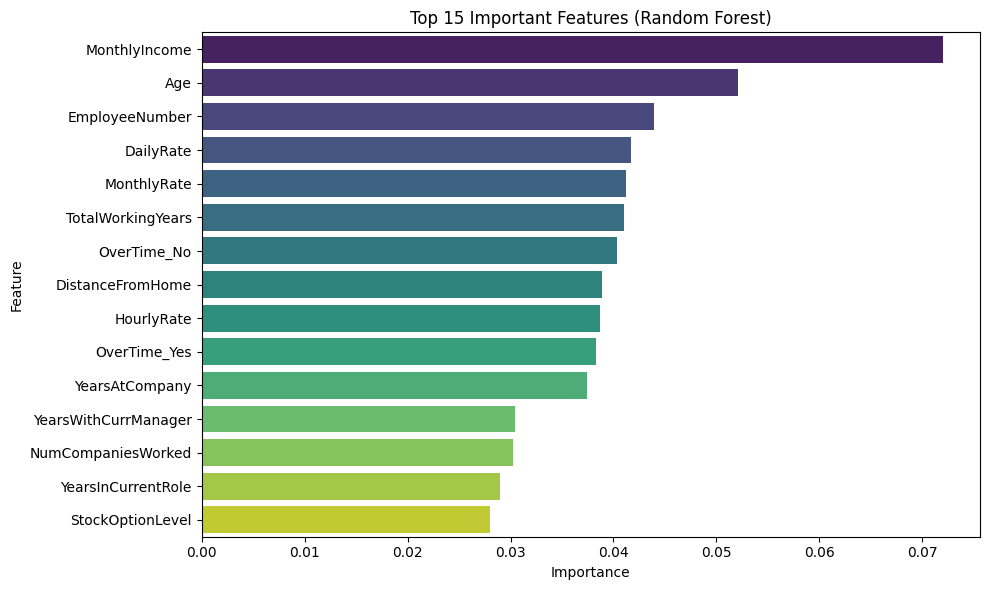

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you used the variable 'rf_model' for your RandomForestClassifier
importances = rf_model.feature_importances_
features = X.columns

# Create a DataFrame
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Important Features (Random Forest)')
plt.tight_layout()
plt.show()


Visualization and Insights

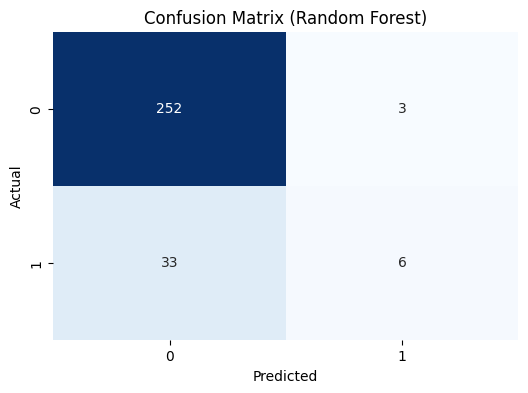

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_model.predict(X_test))

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.show()
